In [1]:
import matplotlib.pyplot as plt
import pyccl as ccl
import numpy as np
import corner
from IPython.display import display, Math
import seaborn as sns
import matplotlib.colors as mcolors
import getdist.plots

In [2]:
# get header from chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2(old).txt

# load header of ("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2(old).txt"
# the header is the lines that start with '#'

def set_parameter_values_from_chain(chain_name):
    header = []
    with open("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{}".format(chain_name), 'r') as f:
        # only read the top lines until it doesn't start with '#'
        for line in f:
            if line.startswith('#'):
                header.append(line.strip()[3:])
            else:
                break
        

    # from header, extract the parameter names and values, which are after 'Parameter values and priors:'
    parameter_values = {}
    parameter_names = []
    flag_params = False
    for item in header:
        if flag_params:
            # split by comma, then by '='
            params = item.split(',')
            for param in params:
                name, value = param.split('=')
                name = name.strip()
                value = float(value.strip())
                parameter_values[name] = value
                parameter_names.append(name)
            flag_params = False
        if item.startswith(' Parameter values and priors:'):
            flag_params = True
            continue

    cosmo_universe = ccl.Cosmology(Omega_c=parameter_values['Omega_m'] - parameter_values['Omega_b'], Omega_b=parameter_values['Omega_b'], 
                                h=parameter_values['h'], A_s=parameter_values['A_s'], n_s=parameter_values['n_s'])

    f_phi_universe = parameter_values['f_phi']
    Bias_distribution_fiducial = np.array([parameter_values['b1'], parameter_values['b2'], parameter_values['b3'], parameter_values['b4'], parameter_values['b5']])

    #["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]
    fiducials = [cosmo_universe["Omega_m"], f_phi_universe, cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
            cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
            Bias_distribution_fiducial[0], Bias_distribution_fiducial[1],\
            Bias_distribution_fiducial[2],Bias_distribution_fiducial[3],\
            Bias_distribution_fiducial[4]]
    
    return cosmo_universe, parameter_names, parameter_values, fiducials

def get_prior_dict_from_chain(chain_name):
    header = []
    """
    Extract prior information from the chain file header. It looks like this:
    # # Priors: 
# # Omega_m: [0.275, 0.33] 
# # f_phi: [0.02, 1.0] 
# # A_s: [1.45, 3.3] 
# # h: [0.61, 0.73] 
# # n_s: [0.85, 1.1] 
# # Omega_b: [0.04, 0.06] 
# # b1: [0.8, 3.0] 
# # b2: [0.8, 3.0] 
# # b3: [0.8, 3.0] 
# # b4: [0.8, 3.0] 
# # b5: [0.8, 3.0] 
find the line that starts with 'Priors:', then read the following lines until the next line that starts with '# #', and extract the parameter names and their prior ranges, which are in the format 'param: [lower, upper]'. Return a dictionary with parameter names as keys and their prior ranges as values.
"""
    with open(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", 'r') as f:
        # only read the top lines until it doesn't start with '#'
        for line in f:
            if line.startswith('#'):
                header.append(line.strip())
            else:
                break
    prior_dict = {}
    flag_priors = False
    for item in header:
        if flag_priors:
            if item.startswith('# #'):
                # split by ':', then by '[', then by ']'
                param, range_str = item.split(':')
                param = param.strip()[4:]
                range_str = range_str.strip()[1:-1]
                lower, upper = range_str.split(',')
                lower = float(lower.strip())
                upper = float(upper.strip())
                prior_dict[param] = (lower, upper)
            else:
                break
        if item.startswith('# # Priors:'):
            flag_priors = True
            continue

    return prior_dict


Removed no burn in
Removed no burn in


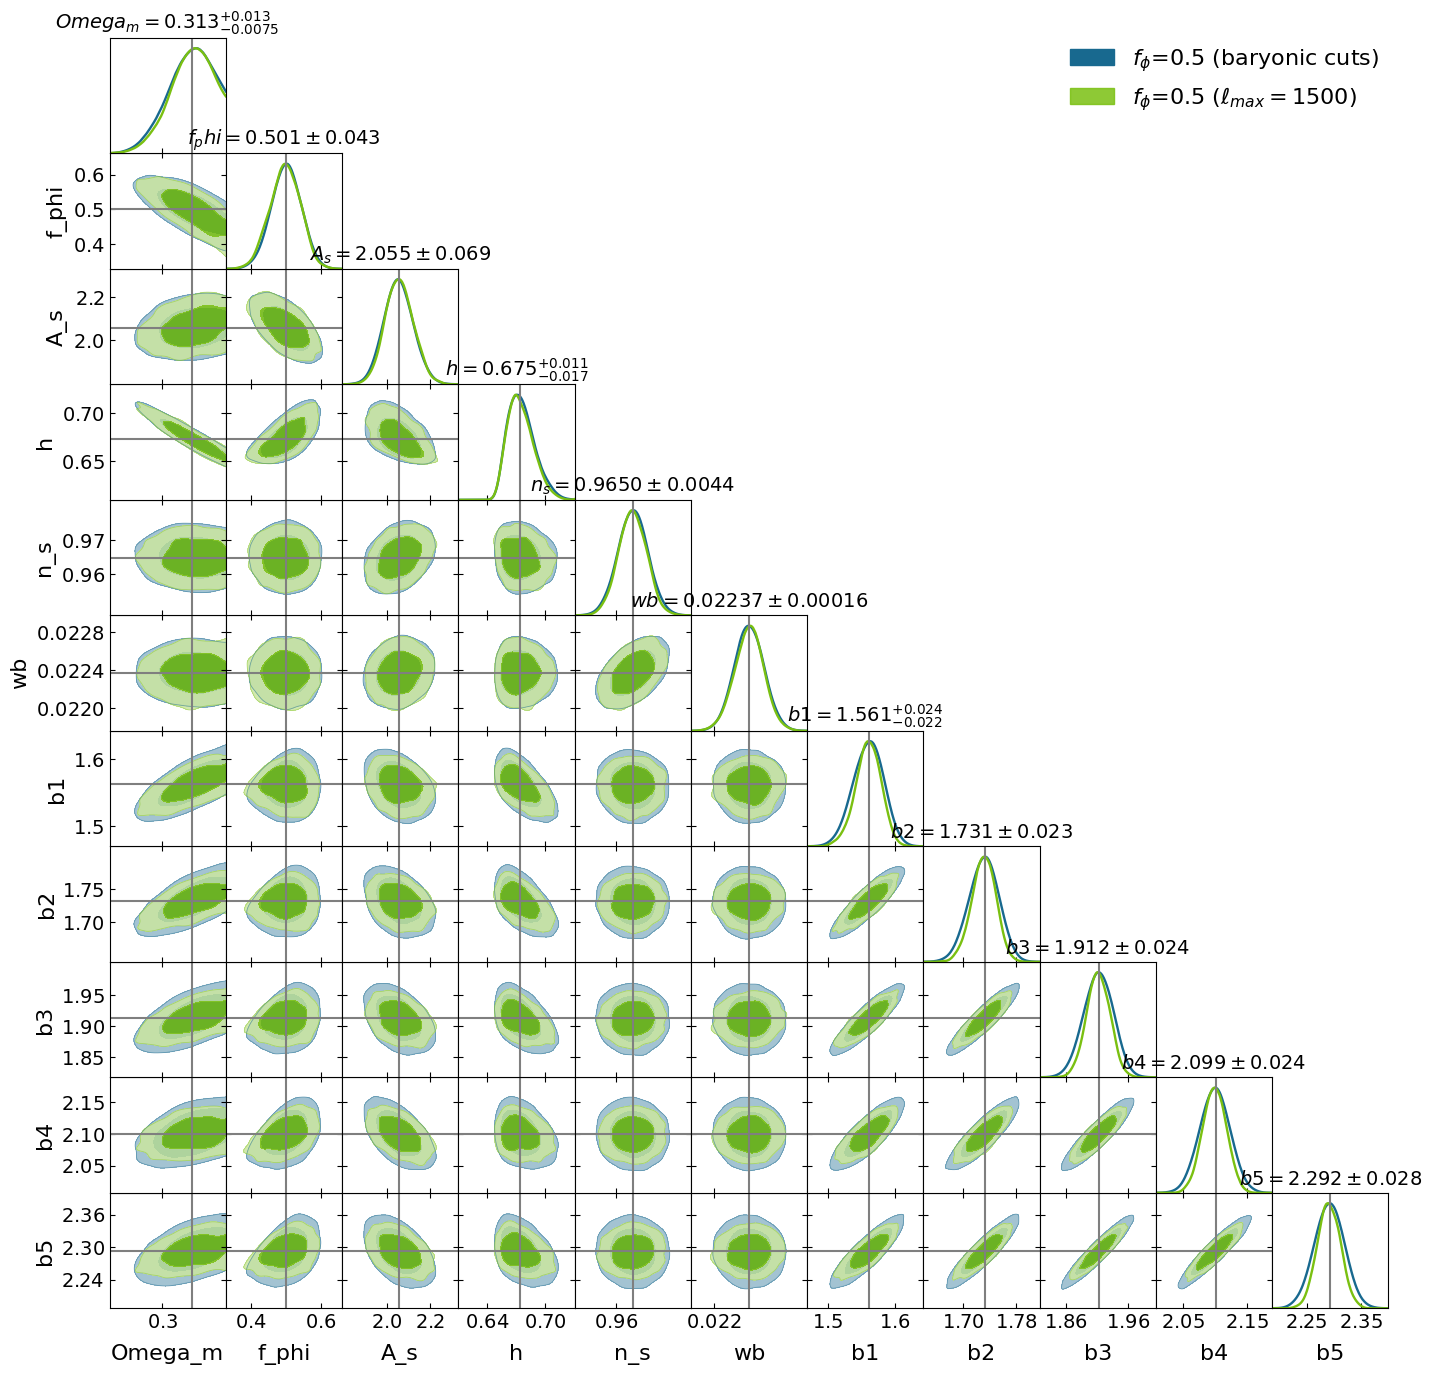

In [5]:
#chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_ell1500_k0p2.txt",
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_ell1500_k0p2.txt"]

#chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_fromemulator_linearcuts_k0p1_fphi1p0.txt",
#                   "chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt", 
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_baryonic_k0p2.txt"]

chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_baryonic_k0p2.txt",
                    "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_ell1500_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])

samples = []

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])

chain_names = ["$f_\phi$=0.5 (baryonic cuts)","$f_\phi$=0.5 ($\ell_{max}=1500$)"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    parameter_names_plots = parameter_names.copy()
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    parameter_names_plots[parameter_names.index("Omega_b")] = "wb"
    parameter_values_plots = parameter_values.copy()
    parameter_values_plots["wb"] = parameter_values["Omega_b"]*parameter_values["h"]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),loglikes=data[:, -1], 
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict)  
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""   
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4   
g.settings.figure_legend_frame = False

g.triangle_plot(samples,
    parameter_names_plots,
    legend_labels=chain_names,
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(parameter_names_plots)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')




In [ ]:
#chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_ell1500_k0p2.txt",
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_ell1500_k0p2.txt"]

chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_fromemulator_linearcuts_k0p1_fphi1p0.txt",
                   "chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt", 
                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_baryonic_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])

samples = []

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])

chain_names = ["$f_\phi$=1.0 (linear cuts)","N-body (ECOSMOG, baryonic cuts)", "$f_\phi$=1.0 (baryonic cuts)"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    parameter_names_plots = parameter_names.copy()
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    parameter_names_plots[parameter_names.index("Omega_b")] = "wb"
    parameter_values_plots = parameter_values.copy()
    parameter_values_plots["wb"] = parameter_values["Omega_b"]*parameter_values["h"]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),loglikes=data[:, -1], 
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict)  
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""   
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4   
g.settings.figure_legend_frame = False

g.triangle_plot(samples,
    parameter_names_plots,
    legend_labels=chain_names,
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(parameter_names_plots)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')




In [ ]:
# print best fit values (max likelihood) and std for all parameters for all chains


# print best fit values (max likelihood) and std for all parameters for all chains
for sample in samples:
    print("##### Getting stats for sample: %s" % chain_name_list[samples.index(sample)])
    stats = sample.getMargeStats()
    for param in parameter_names_plots[:2]:
        print("Parameter: %s" % param)
        lims = stats.parWithName(param).limits
        # create variable lim_{param} for each param, which is a list of the limits for each confidence level
        exec("lims_%s = lims" % param)
        # set lims_{param} to be the limits for the parameter with name {param}
        exec("lims_%s = stats.parWithName('%s').limits" % (param, param))
        
    # print the limits for each parameter and confidence level
    for param in parameter_names_plots[:2]:
        exec("lims = lims_%s" % param)
        for conf, lim in zip(sample.contours, lims):
            print("%s %s%% lower: %.4f upper: %.4f (%s)" % (param, conf, lim.lower, lim.upper, lim.limitType()))

##### Getting stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_fromemulator_linearcuts_k0p1_fphi1p0.txt
Parameter: Omega_m
Parameter: f_phi
Omega_m 0.68% lower: 0.3042 upper: 0.3280 (two tail)
Omega_m 0.95% lower: 0.2900 upper: 0.3300 (one tail lower limit)
Omega_m 0.99% lower: 0.2827 upper: 0.3300 (one tail lower limit)
f_phi 0.68% lower: 0.9770 upper: 1.0000 (one tail lower limit)
f_phi 0.95% lower: 0.9546 upper: 1.0000 (one tail lower limit)
f_phi 0.99% lower: 0.9398 upper: 1.0000 (one tail lower limit)
##### Getting stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt
Parameter: Omega_m
Parameter: f_phi
Omega_m 0.68% lower: 0.2966 upper: 0.3163 (two tail)
Omega_m 0.95% lower: 0.2888 upper: 0.3263 (two tail)
Omega_m 0.99% lower: 0.2844 upper: 0.3300 (one tail lower limit)
f_phi 0.68% lower: 0.9873 upper: 1.0000 (one tail lower limit)
f_phi 0.95% lower: 0.9739 upper: 1.0000 (one tail lower limit)
f_phi 0.99% lower: 0.9654 upper: 1.0000 (one tail lower limit)
##

In [156]:
for sample in samples:
    print("##### Getting stats for sample: %s" % chain_name_list[samples.index(sample)])
    print(sample.getLikeStats())

##### Getting stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_fromemulator_linearcuts_k0p1_fphi1p0.txt
Best fit sample -log(Like) = -77.096789
mean(-Ln(like)) = 7.174624
-Ln(mean like)  = -5.538825
2*Var(Ln(like)) = 10.325420

parameter   bestfit        lower1         upper1         lower2         upper2
Omega_m     3.1998281E-01  2.7501978E-01  3.2997373E-01  2.7501978E-01  3.2999034E-01   
f_phi       9.7890815E-01  7.3462265E-01  9.9999682E-01  7.3462265E-01  9.9999682E-01   
A_s         2.4734075E+00  1.7037347E+00  2.7418000E+00  1.7037347E+00  2.7418000E+00   
h           6.3599649E-01  6.1617381E-01  7.2997991E-01  6.1617381E-01  7.2997991E-01   
n_s         9.8100137E-01  9.2312683E-01  1.0117653E+00  9.2312683E-01  1.0117653E+00   
wb          2.3413008E-02  2.0966033E-02  2.4002946E-02  2.0966033E-02  2.4002946E-02   
b1          1.4855521E+00  1.3290651E+00  1.6969560E+00  1.3290651E+00  1.6969560E+00   
b2          1.7788886E+00  1.4990052E+00  1.8629069E+00  1.4990052E+00  1.

Removed no burn in
Removed no burn in
Removed no burn in


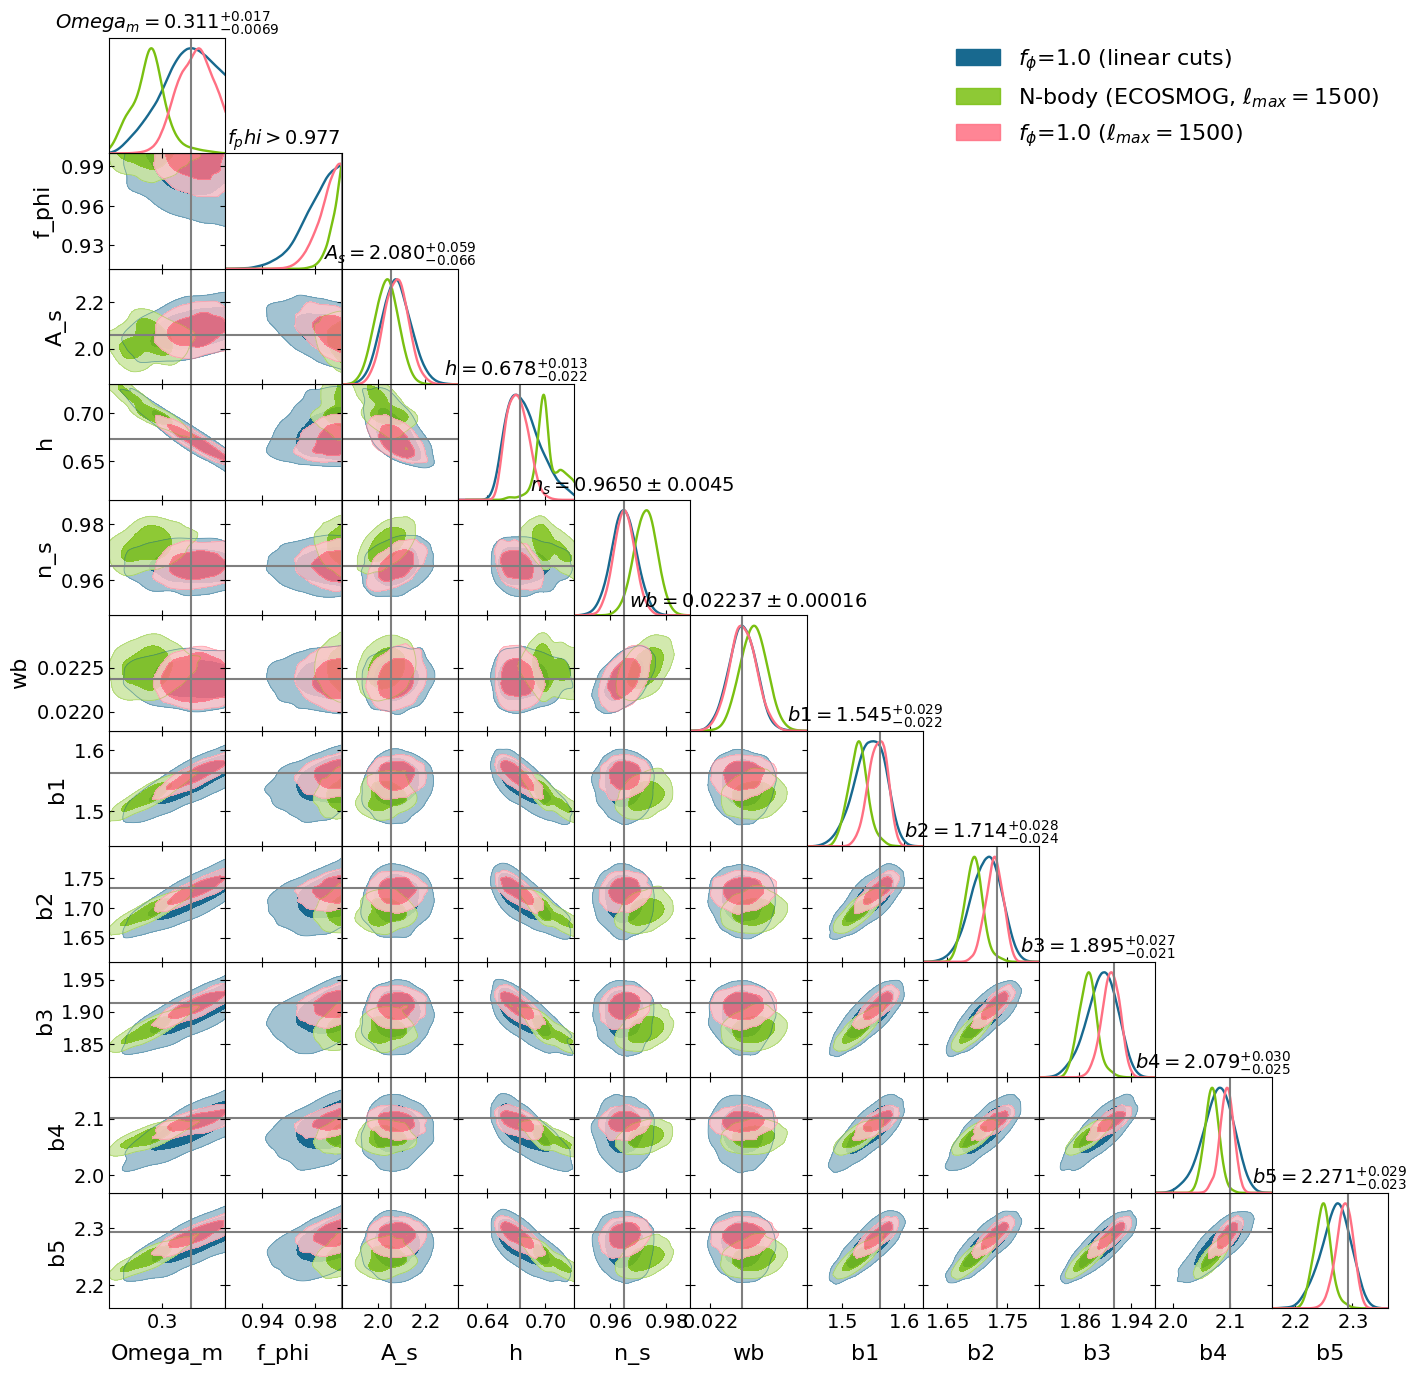

In [140]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_fromemulator_linearcuts_k0p1_fphi1p0.txt",
                    "chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 
                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_ell1500_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])

samples = []

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])


chain_names = ["$f_\phi$=1.0 (linear cuts)","N-body (ECOSMOG, $\ell_{max} = 1500$)", "$f_\phi$=1.0 ($\ell_{max} = 1500$)"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    parameter_names_plots = parameter_names.copy()
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    parameter_names_plots[parameter_names.index("Omega_b")] = "wb"
    parameter_values_plots = parameter_values.copy()
    parameter_values_plots["wb"] = parameter_values["Omega_b"]*parameter_values["h"]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict)
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""   
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4   
g.settings.figure_legend_frame = False

g.triangle_plot(samples,
    parameter_names_plots,
    legend_labels=chain_names,
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(parameter_names_plots)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    


Removed no burn in
Removed no burn in


Text(5, 5, 'Scale cuts: $\\ell_{max}=1500$, $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1')

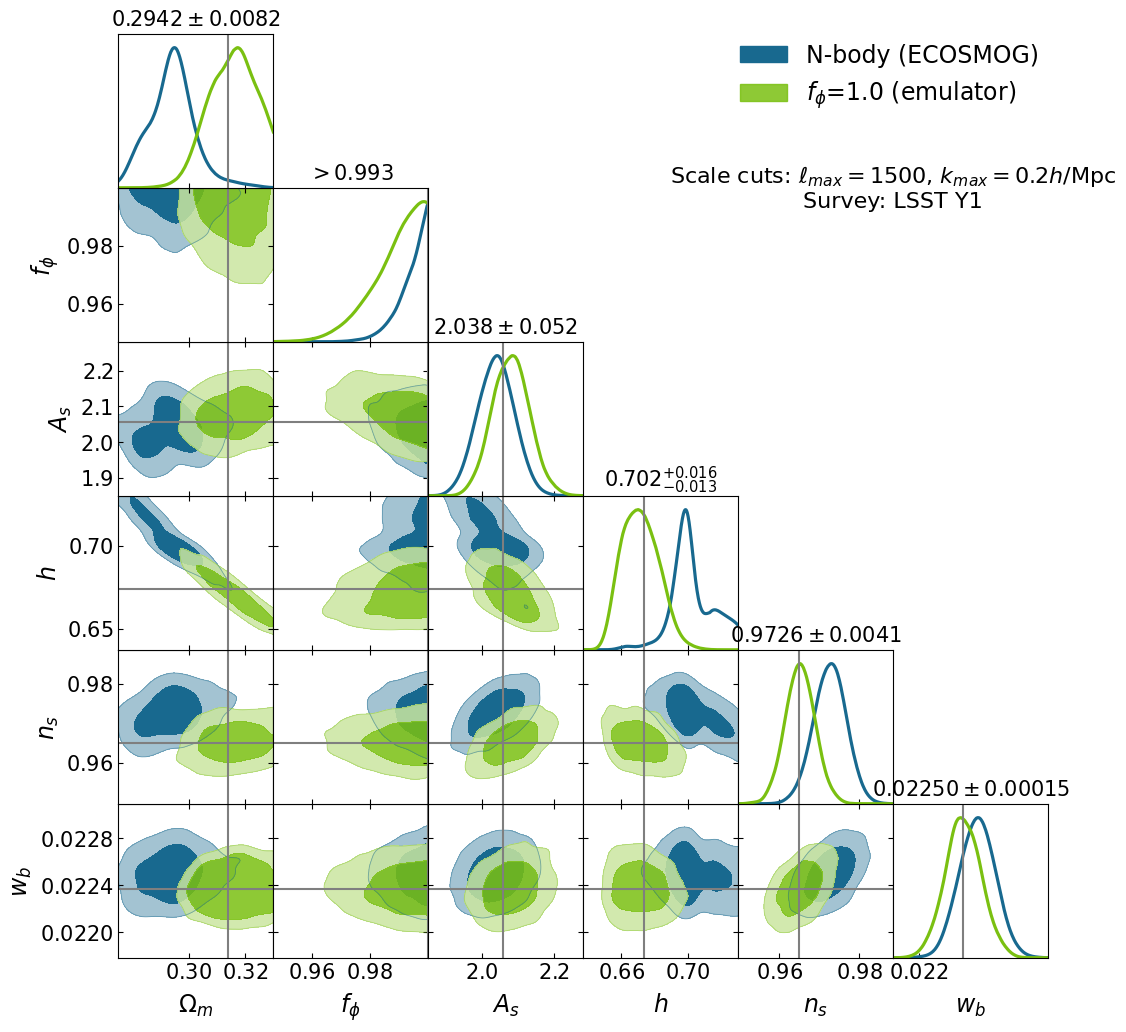

In [20]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 
                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_ell1500_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])


#chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt", 
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_baryonic_k0p2.txt"]
samples = []


# rename parameters
parameter_names_plots = parameter_names.copy()
parameter_names_plots[parameter_names.index("Omega_m")] = r"$\Omega_m$"
parameter_names_plots[parameter_names.index("f_phi")] = r"$f_\phi$"
parameter_names_plots[parameter_names.index("b1")] = r"$b_1$"
parameter_names_plots[parameter_names.index("b2")] = r"$b_2$"
parameter_names_plots[parameter_names.index("b3")] = r"$b_3$"
parameter_names_plots[parameter_names.index("b4")] = r"$b_4$"
parameter_names_plots[parameter_names.index("b5")] = r"$b_5$"
parameter_names_plots[parameter_names.index("A_s")] = r"$A_s$"
parameter_names_plots[parameter_names.index("h")] = r"$h$"
parameter_names_plots[parameter_names.index("n_s")] = r"$n_s$"

parameter_values_plots = parameter_values.copy()
parameter_values_plots[r"$\Omega_m$"] = parameter_values["Omega_m"]
parameter_values_plots[r"$f_\phi$"] = parameter_values["f_phi"]
parameter_values_plots[r"$b_1$"] = parameter_values["b1"]
parameter_values_plots[r"$b_2$"] = parameter_values["b2"]
parameter_values_plots[r"$b_3$"] = parameter_values["b3"]
parameter_values_plots[r"$b_4$"] = parameter_values["b4"]
parameter_values_plots[r"$b_5$"] = parameter_values["b5"]
parameter_values_plots[r"$h$"] = parameter_values["h"]
parameter_values_plots[r"$A_s$"] = parameter_values["A_s"]
parameter_values_plots[r"$n_s$"] = parameter_values["n_s"]

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])
# change prior_dict keys to the names in parameter_names_plots. For Omega_b, change to w_b set prior to None
prior_dict_plots = {}
for key in prior_dict.keys():
    if key == "Omega_b":
        prior_dict_plots[r"$w_b$"] = (None, None)
    else:
        prior_dict_plots[parameter_names_plots[parameter_names.index(key)]] = prior_dict[key]

# change Omega_b to Omega_b*h^2
parameter_names_plots[parameter_names.index("Omega_b")] = r"$w_b$"
parameter_values_plots[r"$w_b$"] = parameter_values["Omega_b"]*parameter_values["h"]**2

# choose parameters to plot
params_to_plot = [r"$\Omega_m$", r"$f_\phi$", r"$A_s$", r"$h$", r"$n_s$", r"$w_b$"]


chain_names = ["N-body (ECOSMOG)", "$f_\phi$=1.0 (emulator)", "$i=1$ (Hi-COLA validation)"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict_plots)
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""   
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
# figure size
g = getdist.plots.getSubplotPlotter(subplot_size=2.0)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4
g.settings.figure_legend_frame = False
g.settings.title_limit_labels = False

g.triangle_plot(samples,
    params_to_plot,
    legend_labels=chain_names,
    # add legend title
    legend_title = 'Model',
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(params_to_plot)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    
# add text saying scale cuts, survey, etc.
text = "Scale cuts: $\\ell_{max}=1500$, $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1"
plt.text(len(params_to_plot)-1, len(params_to_plot)-1, text, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=16)

#plt.savefig("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Figures/corner_plots/triangle_plot_Nbody_emulator_validation.png", dpi=300)

Removed no burn in
Removed no burn in


Text(5, 5, 'Scale cuts: $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1')

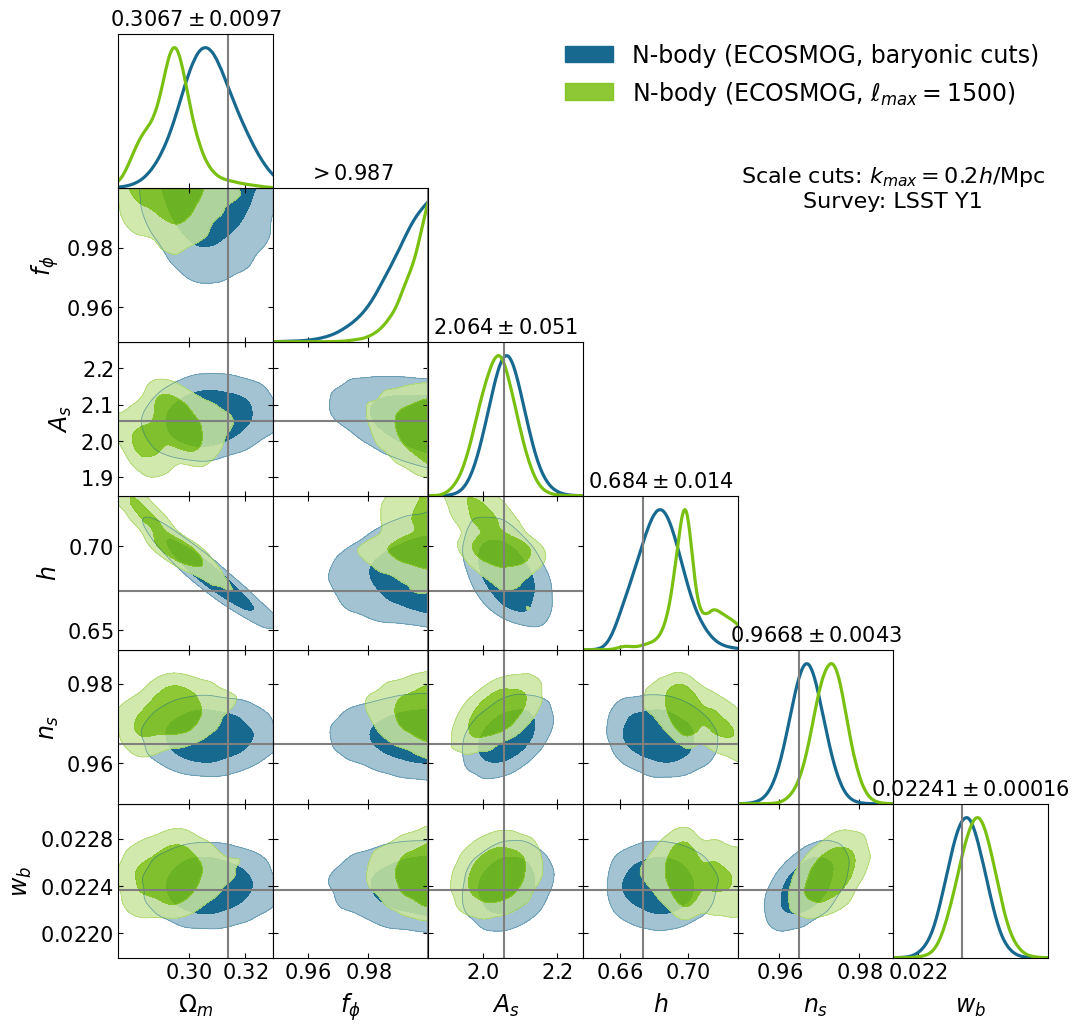

In [ ]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt",
                    "chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])

samples = []

# rename parameters
parameter_names_plots = parameter_names.copy()
parameter_names_plots[parameter_names.index("Omega_m")] = r"$\Omega_m$"
parameter_names_plots[parameter_names.index("f_phi")] = r"$f_\phi$"
parameter_names_plots[parameter_names.index("b1")] = r"$b_1$"
parameter_names_plots[parameter_names.index("b2")] = r"$b_2$"
parameter_names_plots[parameter_names.index("b3")] = r"$b_3$"
parameter_names_plots[parameter_names.index("b4")] = r"$b_4$"
parameter_names_plots[parameter_names.index("b5")] = r"$b_5$"
parameter_names_plots[parameter_names.index("A_s")] = r"$A_s$"
parameter_names_plots[parameter_names.index("h")] = r"$h$"
parameter_names_plots[parameter_names.index("n_s")] = r"$n_s$"

parameter_values_plots = parameter_values.copy()
parameter_values_plots[r"$\Omega_m$"] = parameter_values["Omega_m"]
parameter_values_plots[r"$f_\phi$"] = parameter_values["f_phi"]
parameter_values_plots[r"$b_1$"] = parameter_values["b1"]
parameter_values_plots[r"$b_2$"] = parameter_values["b2"]
parameter_values_plots[r"$b_3$"] = parameter_values["b3"]
parameter_values_plots[r"$b_4$"] = parameter_values["b4"]
parameter_values_plots[r"$b_5$"] = parameter_values["b5"]
parameter_values_plots[r"$h$"] = parameter_values["h"]
parameter_values_plots[r"$A_s$"] = parameter_values["A_s"]
parameter_values_plots[r"$n_s$"] = parameter_values["n_s"]

# change Omega_b to Omega_b*h^2
parameter_names_plots[parameter_names.index("Omega_b")] = r"$w_b$"
parameter_values_plots[r"$w_b$"] = parameter_values["Omega_b"]*parameter_values["h"]**2

# choose parameters to plot
params_to_plot = [r"$\Omega_m$", r"$f_\phi$", r"$A_s$", r"$h$", r"$n_s$", r"$w_b$"]

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])
# change prior_dict keys to the names in parameter_names_plots. For Omega_b, change to w_b set prior to None
prior_dict_plots = {}
for key in prior_dict.keys():
    if key == "Omega_b":
        prior_dict_plots[r"$w_b$"] = (None, None)
    else:
        prior_dict_plots[parameter_names_plots[parameter_names.index(key)]] = prior_dict[key]

chain_names = ["N-body (ECOSMOG, baryonic cuts)","N-body (ECOSMOG, $\ell_{max} = 1500$)"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict_plots)
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""   
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
# figure size
g = getdist.plots.getSubplotPlotter(subplot_size=2.0)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4
g.settings.figure_legend_frame = False
g.settings.title_limit_labels = False

g.triangle_plot(samples,
    params_to_plot,
    legend_labels=chain_names,
    # add legend title
    legend_title = 'Model',
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(params_to_plot)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    
# add text saying scale cuts, survey, etc.
text = "Scale cuts: $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1"
plt.text(len(params_to_plot)-1, len(params_to_plot)-1, text, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=16)

#plt.savefig("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Figures/corner_plots/triangle_plot_Nbody_emulator_validation_baryonic.png", dpi=300)

Removed no burn in
Removed no burn in


Text(5, 5, 'Scale cuts: $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1')

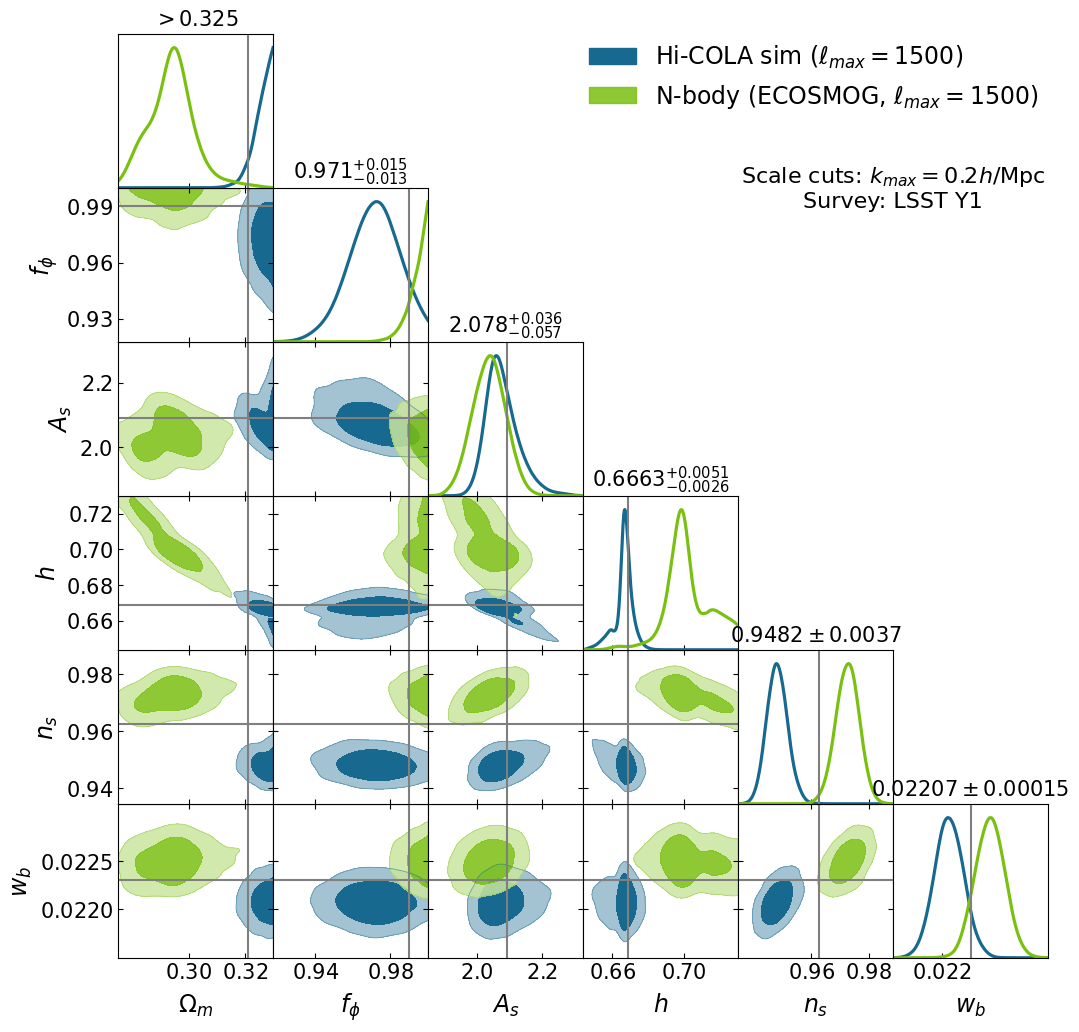

In [23]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validationfiducial_i24_ell1500_k0p2.txt",
                    "chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])

samples = []

# rename parameters
parameter_names_plots = parameter_names.copy()
parameter_names_plots[parameter_names.index("Omega_m")] = r"$\Omega_m$"
parameter_names_plots[parameter_names.index("f_phi")] = r"$f_\phi$"
parameter_names_plots[parameter_names.index("b1")] = r"$b_1$"
parameter_names_plots[parameter_names.index("b2")] = r"$b_2$"
parameter_names_plots[parameter_names.index("b3")] = r"$b_3$"
parameter_names_plots[parameter_names.index("b4")] = r"$b_4$"
parameter_names_plots[parameter_names.index("b5")] = r"$b_5$"
parameter_names_plots[parameter_names.index("A_s")] = r"$A_s$"
parameter_names_plots[parameter_names.index("h")] = r"$h$"
parameter_names_plots[parameter_names.index("n_s")] = r"$n_s$"

parameter_values_plots = parameter_values.copy()
parameter_values_plots[r"$\Omega_m$"] = parameter_values["Omega_m"]
parameter_values_plots[r"$f_\phi$"] = parameter_values["f_phi"]
parameter_values_plots[r"$b_1$"] = parameter_values["b1"]
parameter_values_plots[r"$b_2$"] = parameter_values["b2"]
parameter_values_plots[r"$b_3$"] = parameter_values["b3"]
parameter_values_plots[r"$b_4$"] = parameter_values["b4"]
parameter_values_plots[r"$b_5$"] = parameter_values["b5"]
parameter_values_plots[r"$h$"] = parameter_values["h"]
parameter_values_plots[r"$A_s$"] = parameter_values["A_s"]
parameter_values_plots[r"$n_s$"] = parameter_values["n_s"]

# change Omega_b to Omega_b*h^2
parameter_names_plots[parameter_names.index("Omega_b")] = r"$w_b$"
parameter_values_plots[r"$w_b$"] = parameter_values["Omega_b"]*parameter_values["h"]**2

# choose parameters to plot
params_to_plot = [r"$\Omega_m$", r"$f_\phi$", r"$A_s$", r"$h$", r"$n_s$", r"$w_b$"]

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])
# change prior_dict keys to the names in parameter_names_plots. For Omega_b, change to w_b set prior to None
prior_dict_plots = {}
for key in prior_dict.keys():
    if key == "Omega_b":
        prior_dict_plots[r"$w_b$"] = (None, None)
    else:
        prior_dict_plots[parameter_names_plots[parameter_names.index(key)]] = prior_dict[key]

chain_names = ["Hi-COLA sim ($\ell_{max} = 1500$)","N-body (ECOSMOG, $\ell_{max} = 1500$)"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict_plots)
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""   
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
# figure size
g = getdist.plots.getSubplotPlotter(subplot_size=2.0)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4
g.settings.figure_legend_frame = False
g.settings.title_limit_labels = False

g.triangle_plot(samples,
    params_to_plot,
    legend_labels=chain_names,
    # add legend title
    legend_title = 'Model',
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(params_to_plot)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    
# add text saying scale cuts, survey, etc.
text = "Scale cuts: $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1"
plt.text(len(params_to_plot)-1, len(params_to_plot)-1, text, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=16)

#plt.savefig("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Figures/corner_plots/triangle_plot_Nbody_emulator_validation_baryonic.png", dpi=300)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


AttributeError: 'NoneType' object has no attribute 'axhline'

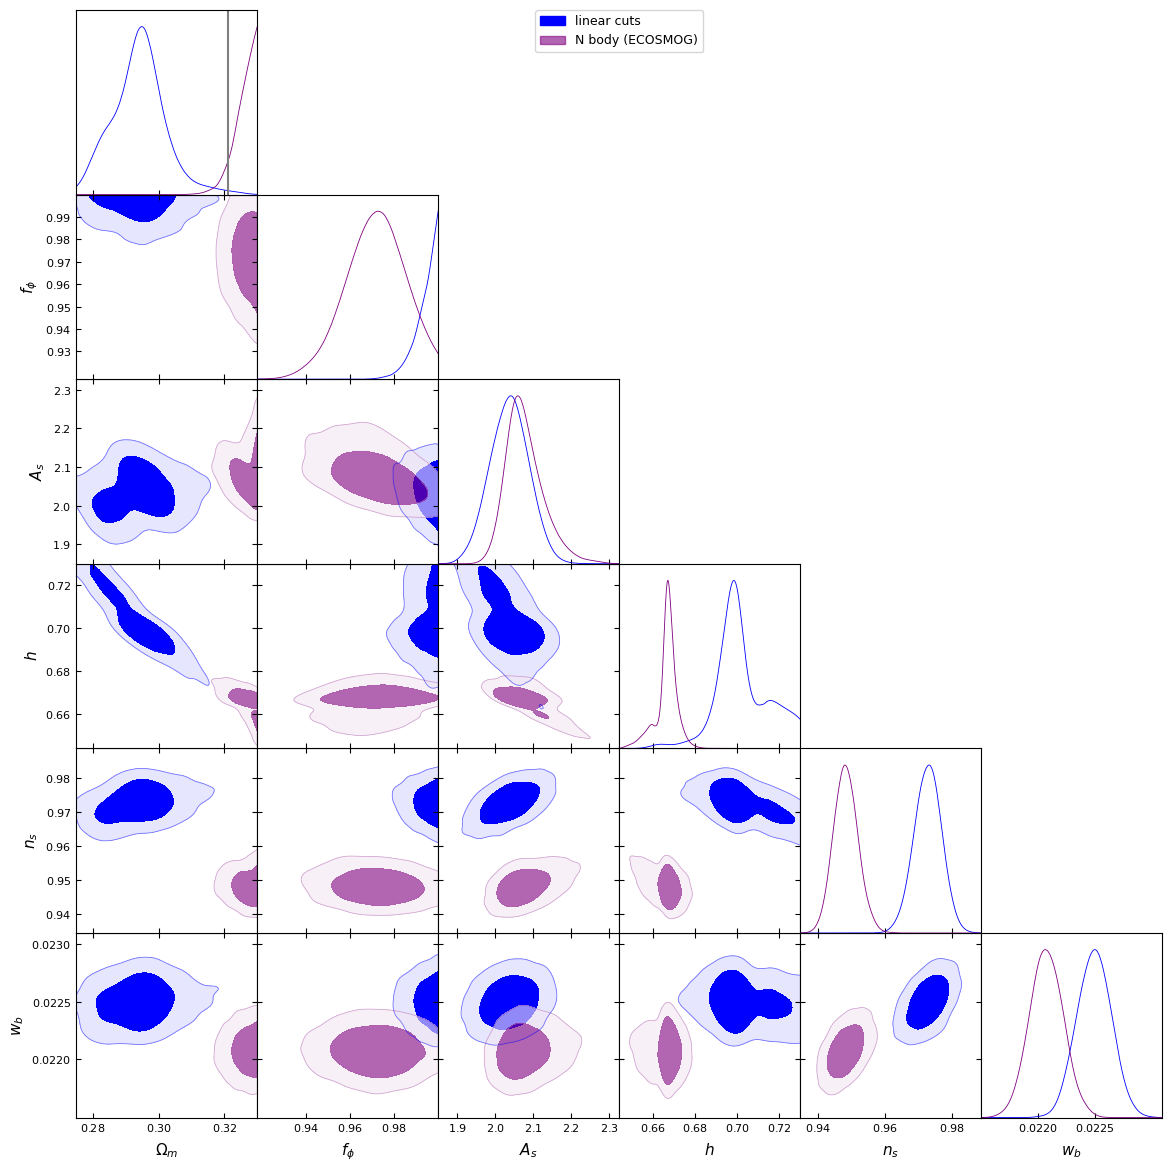

In [22]:
# Variants - plot baryonic cuts on one side, ell=1500 cuts on the other, with lin cuts under both
from matplotlib import cm

g = getdist.plots.get_subplot_plotter()

baryonic_chains =  ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt", 
                   "chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt"]

ell1500_chains = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_ell1500_k0p2.txt", 
                   "chain_mcmc_cG_3x2pt_LSSTY1_validationfiducial_i24_ell1500_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(ell1500_chains[1])

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])
# change prior_dict keys to the names in parameter_names_plots. For Omega_b, change to w_b set prior to None
prior_dict_plots = {}
for key in prior_dict.keys():
    if key == "Omega_b":
        prior_dict_plots[r"$w_b$"] = (None, None)
    else:
        prior_dict_plots[parameter_names_plots[parameter_names.index(key)]] = prior_dict[key]

# get samples for baryonic chains
baryonic_samples = []
for chain_name in baryonic_chains:
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    baryonic_samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict_plots)
    )

# get samples for ell1500 chains
ell1500_samples = []
for chain_name in ell1500_chains:
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    ell1500_samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict_plots)
    )


params_to_plot = [r"$\Omega_m$", r"$f_\phi$", r"$A_s$", r"$h$", r"$n_s$", r"$w_b$"]

upper_kwargs = {
    "contour_colors": ["blue", "purple", "green"],
    "contour_ls": ["-","--", "--"],
    "filled": [True,True, True],
    "show_1d": [True,True, True],
    "contour_lws": [1,1,1],
}
g.settings.solid_contour_palefactor = 0.9
g.settings.alpha_filled_add = 0.6
g.triangle_plot(
    ell1500_samples,
    params_to_plot,
    filled=True,
    contour_colors=["blue", "purple", "green"],
    markers={"x0": -0.5},
    #upper_roots= ell1500_samples,
    upper_kwargs=upper_kwargs,
    upper_label_right=True,
    legend_labels=["linear cuts", "N body (ECOSMOG)", "emulator ($f_\\phi=1.0$)"],
);

# plot fiducial values as gray lines
for i in range(len(params_to_plot)):
    for j in range(len(params_to_plot)):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

{'$\\Omega_m$': (0.275, 0.33), '$f_\\phi$': (0.02, 1.0), '$A_s$': (1.45, 3.3), '$h$': (0.61, 0.73), '$n_s$': (0.85, 1.1), '$w_b$': (None, None), '$b_1$': (0.8, 3.0), '$b_2$': (0.8, 3.0), '$b_3$': (0.8, 3.0), '$b_4$': (0.8, 3.0), '$b_5$': (0.8, 3.0)}
Removed no burn in
Removed no burn in


Text(5, 5, 'Scale cuts: $\\ell_{max}=1500$, $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1')

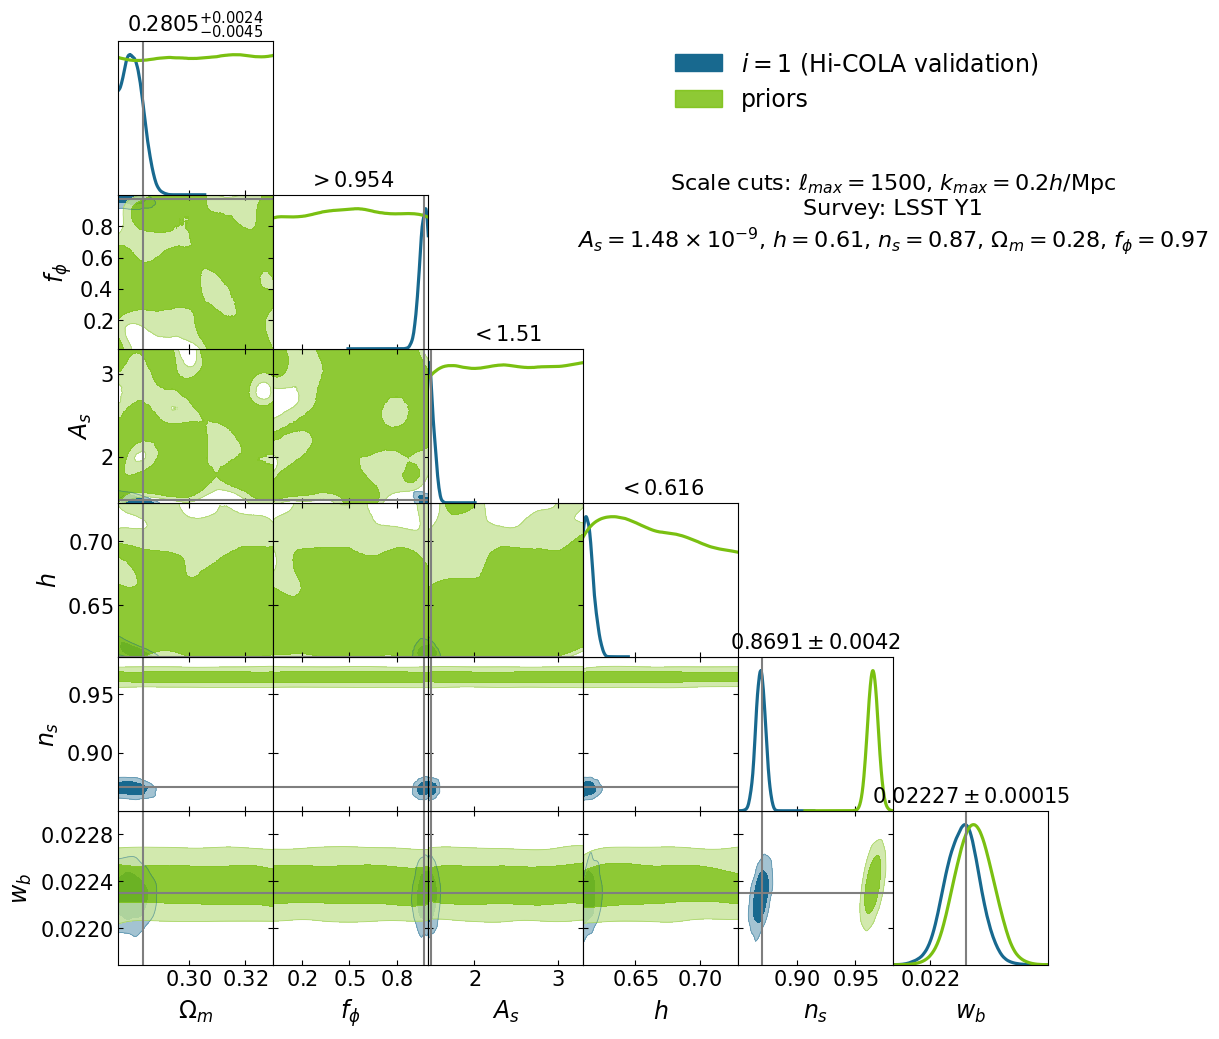

In [ ]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_i1_ell1500_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])

#chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt", 
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_baryonic_k0p2.txt"]
samples = []

# rename parameters
parameter_names_plots = parameter_names.copy()
parameter_names_plots[parameter_names.index("Omega_m")] = r"$\Omega_m$"
parameter_names_plots[parameter_names.index("f_phi")] = r"$f_\phi$"
parameter_names_plots[parameter_names.index("b1")] = r"$b_1$"
parameter_names_plots[parameter_names.index("b2")] = r"$b_2$"
parameter_names_plots[parameter_names.index("b3")] = r"$b_3$"
parameter_names_plots[parameter_names.index("b4")] = r"$b_4$"
parameter_names_plots[parameter_names.index("b5")] = r"$b_5$"
parameter_names_plots[parameter_names.index("A_s")] = r"$A_s$"
parameter_names_plots[parameter_names.index("h")] = r"$h$"
parameter_names_plots[parameter_names.index("n_s")] = r"$n_s$"

parameter_values_plots = parameter_values.copy()
parameter_values_plots[r"$\Omega_m$"] = parameter_values["Omega_m"]
parameter_values_plots[r"$f_\phi$"] = parameter_values["f_phi"]
parameter_values_plots[r"$b_1$"] = parameter_values["b1"]
parameter_values_plots[r"$b_2$"] = parameter_values["b2"]
parameter_values_plots[r"$b_3$"] = parameter_values["b3"]
parameter_values_plots[r"$b_4$"] = parameter_values["b4"]
parameter_values_plots[r"$b_5$"] = parameter_values["b5"]
parameter_values_plots[r"$h$"] = parameter_values["h"]
parameter_values_plots[r"$A_s$"] = parameter_values["A_s"]
parameter_values_plots[r"$n_s$"] = parameter_values["n_s"]

# change Omega_b to Omega_b*h^2
parameter_names_plots[parameter_names.index("Omega_b")] = r"$w_b$"
parameter_values_plots[r"$w_b$"] = parameter_values["Omega_b"]*parameter_values["h"]**2


# choose parameters to plot
params_to_plot = [r"$\Omega_m$", r"$f_\phi$", r"$A_s$", r"$h$", r"$n_s$", r"$w_b$"]

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])
# change prior_dict keys to the names in parameter_names_plots. For Omega_b, change to w_b set prior to None
prior_dict_plots = {}
for key in prior_dict.keys():
    if key == "Omega_b":
        prior_dict_plots[r"$w_b$"] = (None, None)
    else:
        prior_dict_plots[parameter_names_plots[parameter_names.index(key)]] = prior_dict[key]

chain_names = ["$i=1$ (Hi-COLA validation)", "priors"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, 
                          weights=np.exp(data[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1},
                           ranges=prior_dict_plots)
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines

data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, 
                      weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35, "mult_bias_correction_order": 1}, ranges=prior_dict_plots)
)

colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
# figure size
g = getdist.plots.getSubplotPlotter(subplot_size=2.0)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4
g.settings.figure_legend_frame = False
g.settings.title_limit_labels = False

g.triangle_plot(samples,
    params_to_plot,
    legend_labels=chain_names,
    # add legend title
    legend_title = 'Model',
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(params_to_plot)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    
# add text saying scale cuts, survey, etc.
text1 = (
    # A_s displayed as x * 10^(-9)
    f"$A_s={parameter_values['A_s']*1e9:.2f} \\times $"+"$10^{-9}$, "
    f"$h={parameter_values['h']:.2f}$, "
    f"$n_s={parameter_values['n_s']:.2f}$, "
    f"$\\Omega_m={parameter_values['Omega_m']:.2f}$, "
    f"$f_\\phi={parameter_values['f_phi']:.2f}$"
)
text = "Scale cuts: $\\ell_{max}=1500$, $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1"
plt.text(len(params_to_plot)-1, len(params_to_plot)-1.3, text1, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=16)
plt.text(len(params_to_plot)-1, len(params_to_plot)-1, text, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=16)

#plt.savefig("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Figures/corner_plots/triangle_plot_validation_i1_ell1500_k0p2.png", dpi=300)

Removed no burn in
Removed no burn in
Removed no burn in


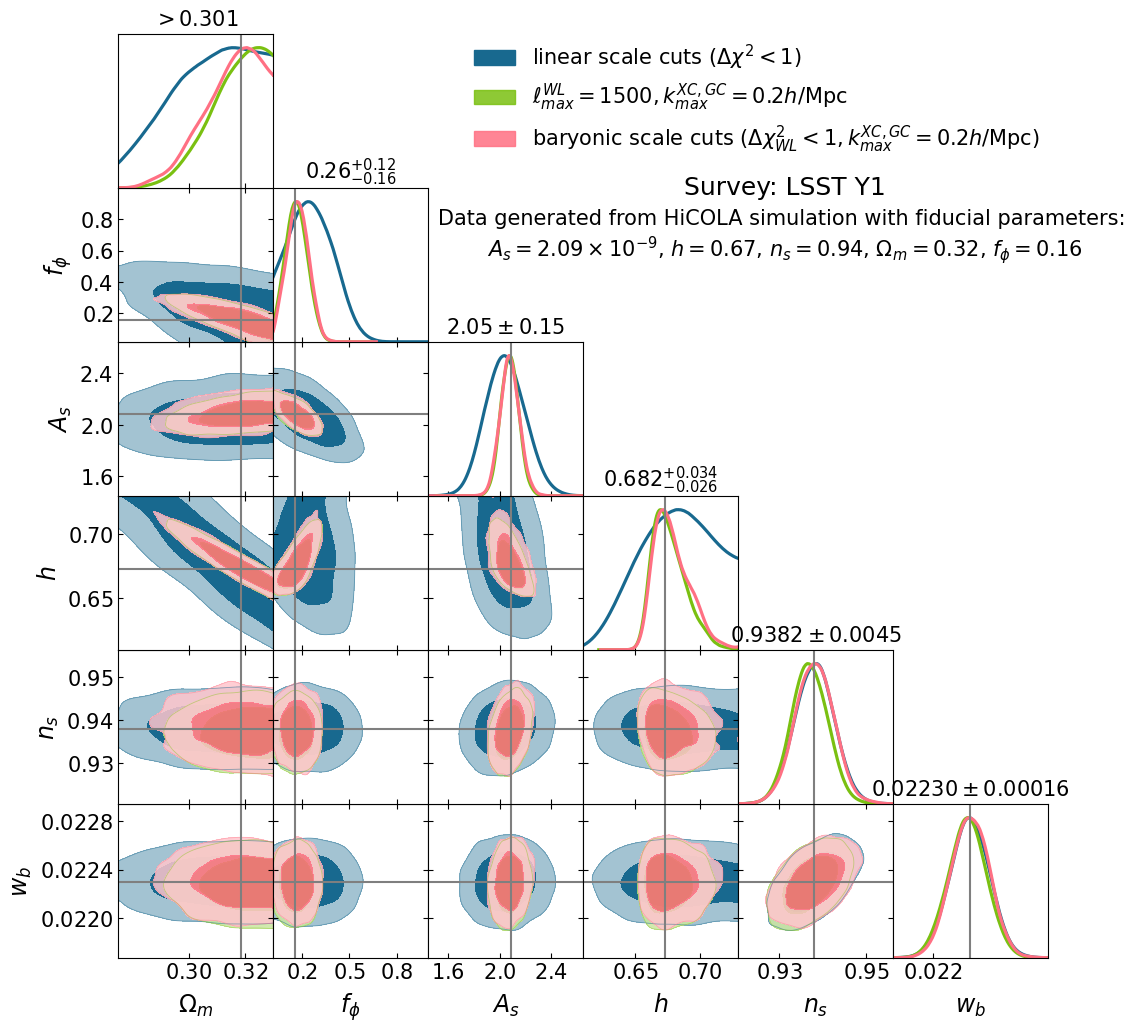

In [190]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_linear_k0p2_linearmodel_newcuts.txt",
                   "chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_ell1500_k0p2.txt",
    "chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_baryonic_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])


#chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt", 
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_baryonic_k0p2.txt"]
samples = []

# rename parameters
parameter_names_plots = parameter_names.copy()
parameter_names_plots[parameter_names.index("Omega_m")] = r"$\Omega_m$"
parameter_names_plots[parameter_names.index("f_phi")] = r"$f_\phi$"
parameter_names_plots[parameter_names.index("b1")] = r"$b_1$"
parameter_names_plots[parameter_names.index("b2")] = r"$b_2$"
parameter_names_plots[parameter_names.index("b3")] = r"$b_3$"
parameter_names_plots[parameter_names.index("b4")] = r"$b_4$"
parameter_names_plots[parameter_names.index("b5")] = r"$b_5$"
parameter_names_plots[parameter_names.index("A_s")] = r"$A_s$"
parameter_names_plots[parameter_names.index("h")] = r"$h$"
parameter_names_plots[parameter_names.index("n_s")] = r"$n_s$"

parameter_values_plots = parameter_values.copy()
parameter_values_plots[r"$\Omega_m$"] = parameter_values["Omega_m"]
parameter_values_plots[r"$f_\phi$"] = parameter_values["f_phi"]
parameter_values_plots[r"$b_1$"] = parameter_values["b1"]
parameter_values_plots[r"$b_2$"] = parameter_values["b2"]
parameter_values_plots[r"$b_3$"] = parameter_values["b3"]
parameter_values_plots[r"$b_4$"] = parameter_values["b4"]
parameter_values_plots[r"$b_5$"] = parameter_values["b5"]
parameter_values_plots[r"$h$"] = parameter_values["h"]
parameter_values_plots[r"$A_s$"] = parameter_values["A_s"]
parameter_values_plots[r"$n_s$"] = parameter_values["n_s"]

# change Omega_b to Omega_b*h^2
parameter_names_plots[parameter_names.index("Omega_b")] = r"$w_b$"
parameter_values_plots[r"$w_b$"] = parameter_values["Omega_b"]*parameter_values["h"]**2

# choose parameters to plot
params_to_plot = [r"$\Omega_m$", r"$f_\phi$", r"$A_s$", r"$h$", r"$n_s$", r"$w_b$"]

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])
# change prior_dict keys to the names in parameter_names_plots. For Omega_b, change to w_b set prior to None
prior_dict_plots = {}
for key in prior_dict.keys():
    if key == "Omega_b":
        prior_dict_plots[r"$w_b$"] = (None, None)
    else:
        prior_dict_plots[parameter_names_plots[parameter_names.index(key)]] = prior_dict[key]


chain_names = ["linear scale cuts $( \Delta\chi^2 < 1)$",
               "$\ell_{max}^{WL} = 1500, k_{max}^{XC,GC} = 0.2 h/\\mathrm{Mpc}$",
               "baryonic scale cuts $(\Delta\chi^2_{WL} < 1, k_{max}^{XC,GC}=0.2 h/\\mathrm{Mpc})$"]

for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),loglikes=data[:, -1], 
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35,"mult_bias_correction_order": 1}, ranges=prior_dict_plots)
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines
"""
data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35})  
)
"""  
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
# figure size
g = getdist.plots.getSubplotPlotter(subplot_size=2.0)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=18
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4
g.settings.figure_legend_frame = False
g.settings.title_limit_labels = False

g.triangle_plot(samples,
    params_to_plot,
    legend_labels=chain_names,
    # add legend title
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(params_to_plot)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    
# add text saying scale cuts, survey, etc.
text1 = ("Data generated from HiCOLA simulation with fiducial parameters: \n"
    # A_s displayed as x * 10^(-9)
    f"$A_s={parameter_values['A_s']*1e9:.2f} \\times $"+"$10^{-9}$, "
    f"$h={parameter_values['h']:.2f}$, "
    f"$n_s={parameter_values['n_s']:.2f}$, "
    f"$\\Omega_m={parameter_values['Omega_m']:.2f}$, "
    f"$f_\\phi={parameter_values['f_phi']:.2f}$"
)

text = "Survey: LSST Y1"
plt.text(len(params_to_plot)-1.7, len(params_to_plot)-1.32,text1, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=15)
plt.text(len(params_to_plot)-1.7, len(params_to_plot)-1, text, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=18)

#lt.savefig("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Figures/corner_plots/triangle_plot_validation_i45_ell1500_baryonic_lin_compared.pdf", dpi=300)

In [168]:
# print best fit values (max likelihood) and std for all parameters for all chains


# print best fit values (max likelihood) and std for all parameters for all chains
for sample in samples:
    print("##### Getting stats for sample: %s" % chain_name_list[samples.index(sample)])
    stats = sample.getMargeStats()
    for i, param in enumerate(parameter_names_plots[:2]):
        print("Parameter: %s" % param)
        lims = stats.parWithName(param).limits
        # create variable lim_{param} for each param, which is a list of the limits for each confidence level
        exec("lims_%s = lims" % i)
        # set lims_{param} to be the limits for the parameter with name {param}
        exec("lims_%s = stats.parWithName('%s').limits" % (i, param))
        
    # print the limits for each parameter and confidence level
    for i, param in enumerate(parameter_names_plots[:2]):
        exec("lims = lims_%s" % i)
        for conf, lim in zip(sample.contours, lims):
            print("%s %s%% lower: %.4f upper: %.4f (%s)" % (param, conf, lim.lower, lim.upper, lim.limitType()))

##### Getting stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_linear_k0p2_linearmodel_newcuts.txt
Parameter: $\Omega_m$
Parameter: $f_\phi$
$\Omega_m$ 0.68% lower: 0.3007 upper: 0.3300 (one tail lower limit)
$\Omega_m$ 0.95% lower: 0.2750 upper: 0.3300 (none)
$\Omega_m$ 0.99% lower: 0.2750 upper: 0.3300 (none)
$f_\phi$ 0.68% lower: 0.1021 upper: 0.3866 (two tail)
$f_\phi$ 0.95% lower: 0.0200 upper: 0.4927 (one tail upper limit)
$f_\phi$ 0.99% lower: 0.0200 upper: 0.5776 (one tail upper limit)
##### Getting stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_ell1500_k0p2.txt
Parameter: $\Omega_m$
Parameter: $f_\phi$
$\Omega_m$ 0.68% lower: 0.3125 upper: 0.3300 (one tail lower limit)
$\Omega_m$ 0.95% lower: 0.2983 upper: 0.3300 (one tail lower limit)
$\Omega_m$ 0.99% lower: 0.2906 upper: 0.3300 (one tail lower limit)
$f_\phi$ 0.68% lower: 0.0938 upper: 0.2335 (two tail)
$f_\phi$ 0.95% lower: 0.0358 upper: 0.2937 (two tail)
$f_\phi$ 0.99% lower: 0.0200 upper: 0.3263 (o

In [173]:
print(-(0.1021 - 0.3866)/2)
print((0.2442 - 0.1060)/2)

print((0.3866 - 0.1021)/(0.2442 - 0.1060))

0.14225
0.0691
2.058610709117221


In [216]:
# find at how many sigmas the best fit value of f_phi is from zero for the chain with linear cuts

for sample in samples:
    print("\n##### Getting f_phi stats for sample: %s" % chain_name_list[samples.index(sample)])
    marge_stats = sample.getMargeStats()
    param_info = marge_stats.parWithName("$f_\phi$")
    mean_f = param_info.mean
    std_f = param_info.err
    best_fit_index = np.argmax(sample.loglikes)
    best_fit_f = sample[1][best_fit_index]

    print(f"\nf_phi statistics:")
    print(f"  Mean:    {mean_f:.6f}")
    print(f"  Std:     {std_f:.6f}")
    print(f"  Best fit (max loglike): {best_fit_f:.6f}")

    print(f"\nSigmas from zero:")
    print(f"  Mean / std    = {mean_f / std_f:.4f} sigma")
    print(f"  Best fit / std = {best_fit_f / std_f:.4f} sigma")

    print("\n Sigmas from fiducial value of {f_phi}: ".format(f_phi=parameter_values["f_phi"]))
    print(f"  Mean / std    = {(mean_f - parameter_values['f_phi']) / std_f:.4f} sigma")
    print(f"  Best fit / std = {(best_fit_f - parameter_values['f_phi']) / std_f:.4f} sigma")


##### Getting f_phi stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_linear_k0p2_linearmodel_newcuts.txt

f_phi statistics:
  Mean:    0.263139
  Std:     0.133548
  Best fit (max loglike): 0.171286

Sigmas from zero:
  Mean / std    = 1.9704 sigma
  Best fit / std = 1.2826 sigma

 Sigmas from fiducial value of 0.15799076466921524: 
  Mean / std    = 0.7873 sigma
  Best fit / std = 0.0996 sigma

##### Getting f_phi stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_ell1500_k0p2.txt

f_phi statistics:
  Mean:    0.167703
  Std:     0.067563
  Best fit (max loglike): 0.128116

Sigmas from zero:
  Mean / std    = 2.4822 sigma
  Best fit / std = 1.8962 sigma

 Sigmas from fiducial value of 0.15799076466921524: 
  Mean / std    = 0.1438 sigma
  Best fit / std = -0.4422 sigma

##### Getting f_phi stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_baryonic_k0p2.txt

f_phi statistics:
  Mean:    0.175511
  Std:     0.067506
  Best fit (max loglike): 0.167330

Sigm

In [169]:
for sample in samples:
    print("##### Getting stats for sample: %s" % chain_name_list[samples.index(sample)])
    print(sample.getLikeStats())

##### Getting stats for sample: chain_mcmc_cG_3x2pt_LSSTY1_validation_i45_linear_k0p2_linearmodel_newcuts.txt
Best fit sample -log(Like) = -74.143782
mean(-Ln(like)) = 8.067931
-Ln(mean like)  = -2.583771
2*Var(Ln(like)) = 8.523896

parameter    bestfit        lower1         upper1         lower2         upper2
$\Omega_m$   3.2895222E-01  2.7500274E-01  3.2999601E-01  2.7500274E-01  3.2999601E-01   
$f_\phi$     2.1090552E-01  2.0024291E-02  9.8406350E-01  2.0010728E-02  9.8406350E-01   
$A_s$        1.9768194E+00  1.4503950E+00  3.1580309E+00  1.4503950E+00  3.1580309E+00   
$h$          6.5443478E-01  6.1008793E-01  7.2998763E-01  6.1008793E-01  7.2998763E-01   
$n_s$        9.2911550E-01  8.9180215E-01  9.8242942E-01  8.9180215E-01  9.8242942E-01   
$w_b$        2.3726591E-02  2.0481059E-02  2.3883970E-02  2.0481059E-02  2.3883970E-02   
$b_1$        1.5906825E+00  1.0327605E+00  2.3498423E+00  1.0327605E+00  2.3498423E+00   
$b_2$        1.8783458E+00  1.4705998E+00  2.4128587E+00 

Removed no burn in
Removed no burn in
Removed no burn in
0.725728515625


Text(5, 5, 'Scale cuts: $\\ell_{max}=1500$, $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1')

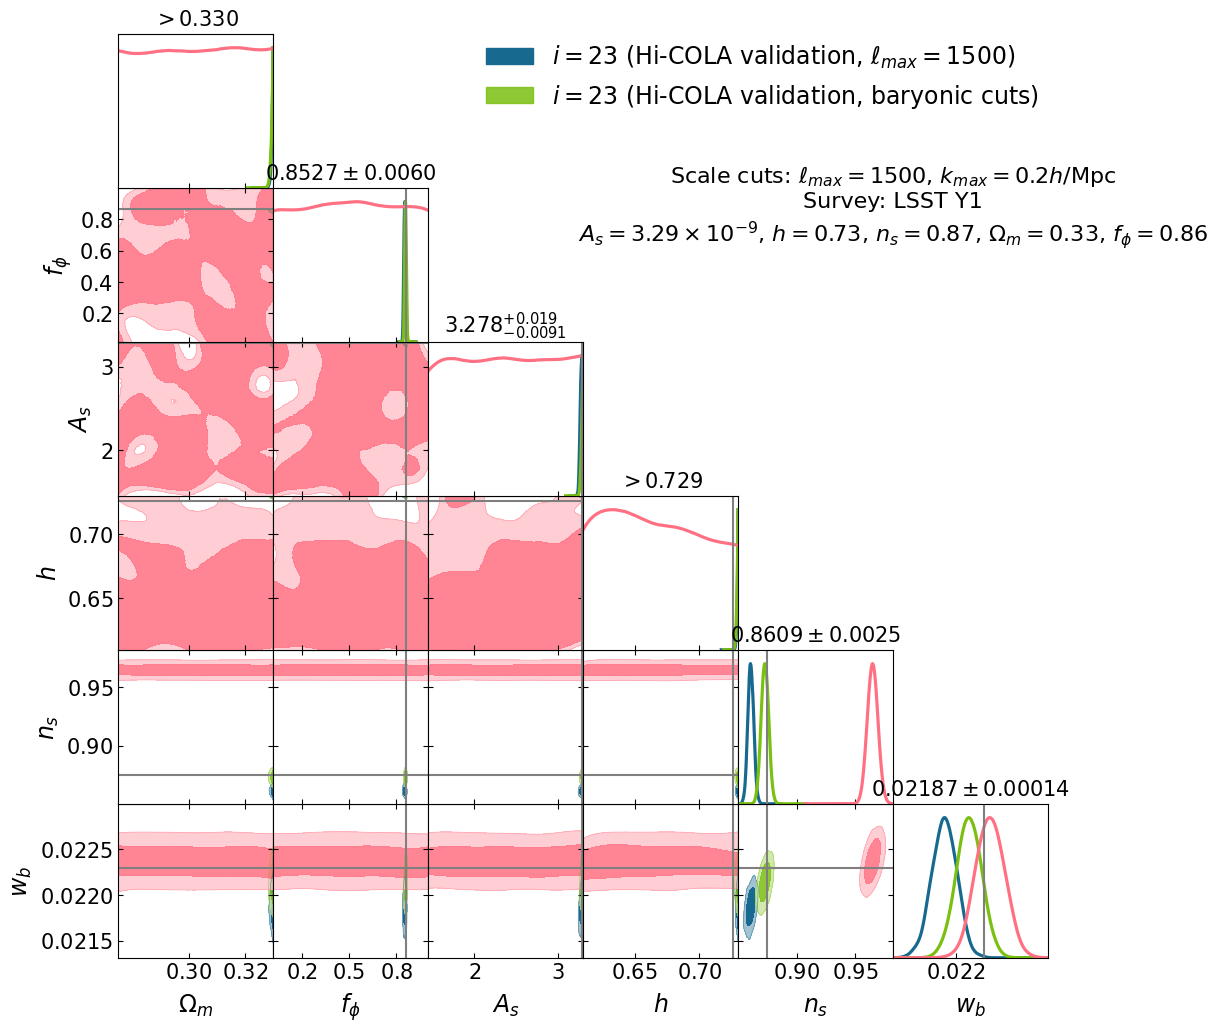

In [145]:
chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_i23_ell1500_k0p2.txt",
                   "chain_mcmc_cG_3x2pt_LSSTY1_validation_i23_baryonic_k0p2.txt"]

cosmo_universe, parameter_names, parameter_values, fiducials = set_parameter_values_from_chain(chain_name_list[0])

#chain_name_list = ["chain_mcmc_cG_3x2pt_LSSTY1_validation_Nbody_baryonic_k0p2.txt", 
#                   "chain_mcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi1p0_baryonic_k0p2.txt"]
samples = []

# rename parameters
parameter_names_plots = parameter_names.copy()
parameter_names_plots[parameter_names.index("Omega_m")] = r"$\Omega_m$"
parameter_names_plots[parameter_names.index("f_phi")] = r"$f_\phi$"
parameter_names_plots[parameter_names.index("b1")] = r"$b_1$"
parameter_names_plots[parameter_names.index("b2")] = r"$b_2$"
parameter_names_plots[parameter_names.index("b3")] = r"$b_3$"
parameter_names_plots[parameter_names.index("b4")] = r"$b_4$"
parameter_names_plots[parameter_names.index("b5")] = r"$b_5$"
parameter_names_plots[parameter_names.index("A_s")] = r"$A_s$"
parameter_names_plots[parameter_names.index("h")] = r"$h$"
parameter_names_plots[parameter_names.index("n_s")] = r"$n_s$"

parameter_values_plots = parameter_values.copy()
parameter_values_plots[r"$\Omega_m$"] = parameter_values["Omega_m"]
parameter_values_plots[r"$f_\phi$"] = parameter_values["f_phi"]
parameter_values_plots[r"$b_1$"] = parameter_values["b1"]
parameter_values_plots[r"$b_2$"] = parameter_values["b2"]
parameter_values_plots[r"$b_3$"] = parameter_values["b3"]
parameter_values_plots[r"$b_4$"] = parameter_values["b4"]
parameter_values_plots[r"$b_5$"] = parameter_values["b5"]
parameter_values_plots[r"$h$"] = parameter_values["h"]
parameter_values_plots[r"$A_s$"] = parameter_values["A_s"]
parameter_values_plots[r"$n_s$"] = parameter_values["n_s"]

# change Omega_b to Omega_b*h^2
parameter_names_plots[parameter_names.index("Omega_b")] = r"$w_b$"
parameter_values_plots[r"$w_b$"] = parameter_values["Omega_b"]*parameter_values["h"]**2

# choose parameters to plot
params_to_plot = [r"$\Omega_m$", r"$f_\phi$", r"$A_s$", r"$h$", r"$n_s$", r"$w_b$"]

# get priors dictionary values for parameters
prior_dict = get_prior_dict_from_chain(chain_name_list[0])
# change prior_dict keys to the names in parameter_names_plots. For Omega_b, change to w_b set prior to None
prior_dict_plots = {}
for key in prior_dict.keys():
    if key == "Omega_b":
        prior_dict_plots[r"$w_b$"] = (None, None)
    else:
        prior_dict_plots[parameter_names_plots[parameter_names.index(key)]] = prior_dict[key]

chain_names = ["$i=23$ (Hi-COLA validation, $\ell_{max} = 1500$)", "$i=23$ (Hi-COLA validation, baryonic cuts)"]
for chain_name in chain_name_list:
    # load the chain, skipping the header lines that start with '#'
    data = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/chains/{chain_name}", comments='#')
    # change Omega_b to Omega_b*h^2
    data[:, parameter_names.index("Omega_b")] = data[:, parameter_names.index("Omega_b")]*data[:, parameter_names.index("h")]**2
    samples.append(
        getdist.MCSamples(samples=data[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data[:, -2]),
                          settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35, "mult_bias_correction_order": 1}, ranges=prior_dict_plots)
    )

# overlay plot of priors from priorchain_tests.txt, with dashed black lines

data_prior = np.loadtxt(f"/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/priorchain_tests.txt", comments='#')
data_prior[:, parameter_names.index("Omega_b")] = data_prior[:, parameter_names.index("Omega_b")]*data_prior[:, parameter_names.index("h")]**2   
samples.append(
    getdist.MCSamples(samples=data_prior[:,:len(parameter_names)], names=parameter_names_plots, weights=np.exp(data_prior[:, -2]),
                      settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35, "mult_bias_correction_order": 1}, ranges=prior_dict_plots)
)

colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
# figure size
g = getdist.plots.getSubplotPlotter(subplot_size=2.0)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4
g.settings.figure_legend_frame = False
g.settings.title_limit_labels = False

g.triangle_plot(samples,
    params_to_plot,
    legend_labels=chain_names,
    # add legend title
    legend_title = 'Model',
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':True, 'color': colors[3], 'ls': '--'},{'filled':False, 'color': "k", 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '-'}, {'color': "k", 'ls': '--'}],)

# plot fiducial values as gray lines
for i in range(len(params_to_plot)):
    for j in range(i+1):
        ax = g.subplots[i,j]
        if i != j and parameter_names_plots[i] in parameter_values_plots and fiducials[i] != None:
            ax.axhline(fiducials[i],lw=1.5,color='tab:gray')
        if parameter_names_plots[j] in parameter_values_plots and fiducials[j] != None:
            ax.axvline(fiducials[j],lw=1.5,color='tab:gray')

    
# add text saying scale cuts, survey, etc.
text1 = (
    # A_s displayed as x * 10^(-9)
    f"$A_s={parameter_values['A_s']*1e9:.2f} \\times $"+"$10^{-9}$, "
    f"$h={parameter_values['h']:.2f}$, "
    f"$n_s={parameter_values['n_s']:.2f}$, "
    f"$\\Omega_m={parameter_values['Omega_m']:.2f}$, "
    f"$f_\\phi={parameter_values['f_phi']:.2f}$"
)
print(parameter_values['h'])
text = "Scale cuts: $\\ell_{max}=1500$, $k_{max}=0.2 h/\\mathrm{Mpc}$\nSurvey: LSST Y1"
plt.text(len(params_to_plot)-1, len(params_to_plot)-1.3, text1, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=16)
plt.text(len(params_to_plot)-1, len(params_to_plot)-1, text, ha='center', va='center',transform=g.subplots[len(params_to_plot)-1,0].transAxes, fontsize=16)

#plt.savefig("/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/Figures/corner_plots/triangle_plot_validation_i23_ell1500_k0p2.png", dpi=300)

### Figure out if priors are an issue

In [ ]:
# run short chain for log prior to sample prior space
import multiprocessing
import scipy

import yaml
from nautilus import Prior, Sampler


config_file = "/home/c2042999/Desktop/Newcastle/cG_Forecasts/CubicGalileon_Forecasts/ini_files/config_run_ell1500_k0p2_Nbody.yaml"
# read the config file
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)


sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

with open(config['data']['params'], 'r') as f:
        params = yaml.safe_load(f)

# add additional bespoke priors if needed
def log_prior(theta_dict):
    theta = [float(theta_dict[key]) for key in ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]]
    Omega_c, f_phi, A_s1e9, h, n_s, Omega_b, b1, b2, b3, b4, b5 = theta 
    priors = params['priors']
    if not priors['Planck_prior']:
        return 0.0
    else:
        gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)
        return gauss_funct.logpdf([n_s, Omega_b*h**2])

# add standard priors
prior = Prior()
params_list = ["Omega_m", "f_phi", "1e9As", "h", "ns", "Omega_b", "b1", "b2", "b3", "b4", "b5"]
for par_i in params_list:
    prior.add_parameter(par_i, dist=(params['priors'][par_i][0], params['priors'][par_i][1]))


sampler = Sampler(prior, log_prior, 
                filepath= 'priorchain_tests.hdf5', resume=config['sampler']['mcmc']['resume'], n_live=config['sampler']['mcmc']['n_live'], pool=multiprocessing.Pool(multiprocessing.cpu_count()))
sampler.run(verbose=bool(config['sampler']['mcmc']['verbose']), discard_exploration=True, n_eff=float(10000))
log_z = sampler.evidence()
points, log_w, log_l = sampler.posterior()

np.savetxt("priorchain_tests.txt", np.c_[points, log_w, log_l], footer='log_Z = {log_z}'.format(log_z=log_z))

In [44]:
#### Get Planck priors #####
# print 1/2sigma values for Omega_b and n_s from Planck prior samples

print("Planck prior 1-sigma for Omega_b:", np.sqrt(cov_prior[1,1])/cosmo_universe["h"]**2)
print("Planck prior 1-sigma for n_s:", np.sqrt(cov_prior[0,0]))
print("value of Omega_b_lower from Planck prior:", mu_prior[1]/cosmo_universe["h"]**2 - np.sqrt(cov_prior[1,1])/cosmo_universe["h"]**2)
print("values of Omega_b_fiducial from Planck prior:", mu_prior[1]/cosmo_universe["h"]**2)
print("value of Omega_b_upper from Planck prior:", mu_prior[1]/cosmo_universe["h"]**2 + np.sqrt(cov_prior[1,1])/cosmo_universe["h"]**2)
print("value of n_s_lower from Planck prior:", mu_prior[0] - np.sqrt(cov_prior[0,0]))
print("value of n_s_upper from Planck prior:", mu_prior[0] + np.sqrt(cov_prior[0,0]))
print("value of n_s_fiducial from Planck prior:", mu_prior[0])

Planck prior 1-sigma for Omega_b: 0.00035031465547806615
Planck prior 1-sigma for n_s: 0.004514538780635848
value of Omega_b_lower from Planck prior: 0.04895138534452194
values of Omega_b_fiducial from Planck prior: 0.049301700000000004
value of Omega_b_upper from Planck prior: 0.04965201465547807
value of n_s_lower from Planck prior: 0.9603854612193641
value of n_s_upper from Planck prior: 0.9694145387806359
value of n_s_fiducial from Planck prior: 0.9649


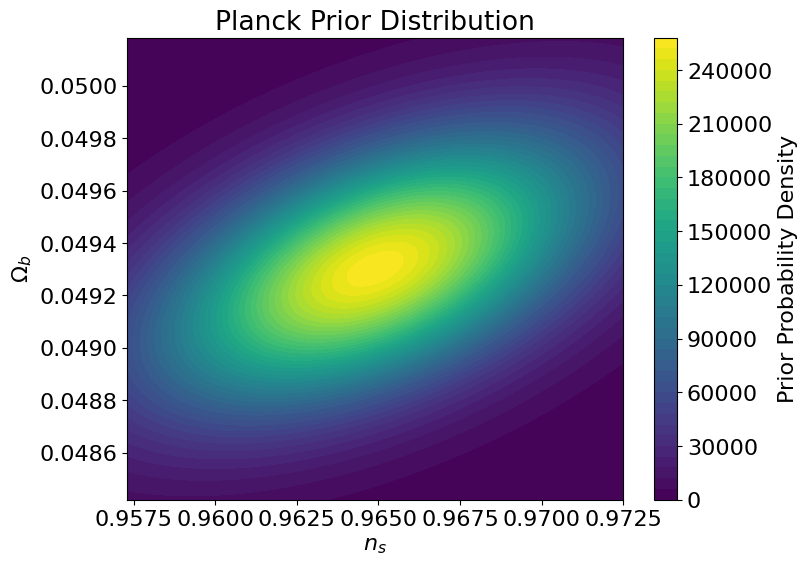

In [39]:
# plot prior distribution for n_s and Omega_b*h^2
import scipy


n_s_range = np.linspace(cosmo_universe['n_s']-0.0038*2, cosmo_universe['n_s']+0.0038*2, 100)
Omega_b_h2_range = np.linspace(cosmo_universe['Omega_b']*cosmo_universe["h"]**2-0.0002*2, cosmo_universe['Omega_b']*cosmo_universe["h"]**2+0.0002*2, 100)
n_s_grid, Omega_b_h2_grid = np.meshgrid(n_s_range, Omega_b_h2_range)
pos = np.dstack((n_s_grid, Omega_b_h2_grid))

prior_val = np.zeros_like(n_s_grid)
for i in range(n_s_grid.shape[0]):
    for j in range(n_s_grid.shape[1]):
        prior_val[i,j] = log_prior({"Omega_m": cosmo_universe["Omega_m"], "f_phi": f_phi_universe, "1e9As": cosmo_universe["A_s"]*1e9, "h": cosmo_universe["h"], "ns": n_s_grid[i,j], "Omega_b": Omega_b_h2_grid[i,j]/cosmo_universe["h"]**2, "b1": Bias_distribution_fiducial[0], "b2": Bias_distribution_fiducial[1], "b3": Bias_distribution_fiducial[2], "b4": Bias_distribution_fiducial[3], "b5": Bias_distribution_fiducial[4]})

plt.figure(figsize=(8,6))
plt.contourf(n_s_grid, Omega_b_h2_grid/cosmo_universe["h"]**2, np.exp(prior_val), levels=50, cmap='viridis')
plt.colorbar(label='Prior Probability Density')
plt.xlabel(r'$n_s$')
plt.ylabel(r'$\Omega_b$')
plt.title('Planck Prior Distribution')
plt.show()




### Run chains for tests in ipynb file

In [56]:
# plot from emcee file
import emcee
# 
filename = "mcmcmcmc_cG_3x2pt_LSSTY1_emulator_cosmo_ecosmog_fphi0p5_ell1500_k0p2.h5"

while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

# You can also manually access the raw chain and other properties
raw_chain = reader.get_chain()#
print(f"Current raw chain shape: {raw_chain.shape}")

tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))

Number of steps completed: 110
Current raw chain shape: (110, 80, 11)
Current iteration: 110
Max 100 x Tau/N: 13.768683727518791


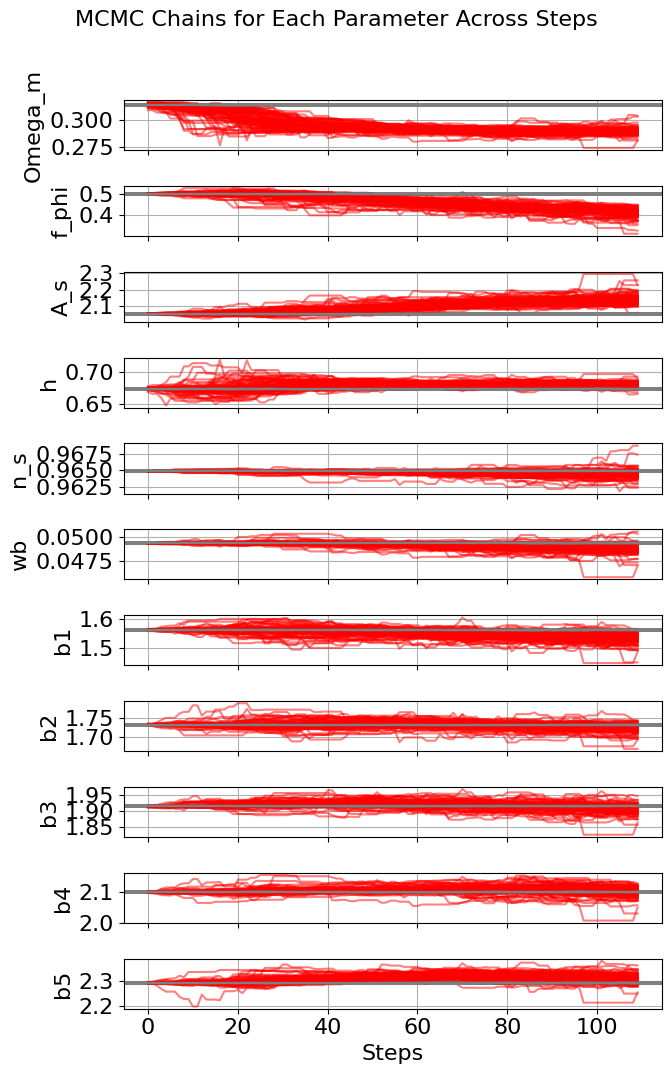

In [ ]:
# Assuming `raw_chain` is the MCMC chain you have loaded from the file.
n_steps, n_walkers, n_params = raw_chain.shape

# Create a figure with subplots, one for each parameter
fig, axes = plt.subplots(n_params, figsize=(7, n_params), sharex=True)

fiducials = [parameter_values[name] for name in parameter_names]
# set A_s fiducial to 1e9 times the value in parameter_values, since we are plotting 1e9As
fiducials[parameter_names.index("A_s")] = parameter_values["A_s"]*1e9
# set f_phi fiducial to 0.5 
fiducials[parameter_names.index("f_phi")] = 0.5
# Iterate over each parameter and plot its evolution
for i in range(n_params):
    ax = axes[i]
    for j in range(n_walkers):
        ax.plot(raw_chain[:, j, i], alpha=0.5, color="r")  # Plot for each walker
        # plot the fiducial parameter values
        ax.axhline(fiducials[i], lw=1.5, color='tab:gray')

    ax.grid()

# Add a label for the shared x-axis (steps/iterations)
axes[-1].set_xlabel("Steps")

# Set the overall title and adjust layout
plt.suptitle("MCMC Chains for Each Parameter Across Steps", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()